<h3> Method with Attention-pooled mean for finding the centeroid embedding of a document and K-Means for clustering. </h3>

<h5> Imports </h5>

In [1]:
import json
import glob
import os

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from kneed import KneeLocator

import shutil

<h5> To avoid the re-embedding from scratch, we just pick-up the embedding results from the files </h5>

In [2]:
# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
files_dir = "data"
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Total documents loaded: {len(all_results)}")

Found 1068 JSON files in data_output/embeddings
Loaded: Fortimo_LED_Strip_5ft_MF_9xx_LV6_embeddings.json
Loaded: dig-sr-connector_embeddings.json
Loaded: Fortimo_LED_Strip_0.25ft_MF_9xx_HV6_x_2pcs_embeddings.json
Loaded: 202308-1-design-in-guide-led-indoor-driver-spot-downlight_embeddings.json
Loaded: SIG-Xitanium-SR-Bridge-DIG-A11_embeddings.json
Loaded: Datasheet_LED_Transformer_75W_24VDC_120-277V_IP67_929003413906_embeddings.json
Loaded: Fortimo-LED-Square-1250lm-9xx-HV-LV3_embeddings.json
Loaded: Fortimo_LED_Strip_CED_1ft_MF_FC_LV5__embeddings.json
Loaded: Fortimo-LED-Strip-PR-FT-2ft-2200lm-927-965-FC-HV5_embeddings.json
Loaded: Datasheet-Fortimo-1100-lm_embeddings.json
Loaded: Fortimo_LED_Line_1ft_MF_8xx_1R_LV5__embeddings.json
Loaded: LED_Transformer_120W_24VDC_913710032567_embeddings.json
Loaded: Fortimo_SLM_C_1201_L09_1313_G7N_HE_plus__embeddings.json
Loaded: Fortimo_LED_Strip_2ft_2200lm_9xx_LV4__embeddings.json
Loaded: Fortimo_FastFlex_2x6_DA_G4plus_embeddings.json
Loaded: Xit

<h5> Compute a PCA Direction from individual chunks (page embeddings) for each document </h5>

In [5]:
import numpy as np

def doc_vector_attention_pool(page_embeddings, alpha=5.0, iters=3):
    """
    Attention-like pooling: pages closer to the center get higher weight.
    page_embeddings: List[np.ndarray] (L2-normalized)
    alpha: sharpness of attention (5–10 works well)
    iters: refinement steps
    """
    if not page_embeddings:
        return None
    
    V = np.vstack(page_embeddings).astype("float32")  # (n,d)
    if len(V) == 1:
        return V[0]

    # start with simple mean
    c = V.mean(axis=0)
    c /= (np.linalg.norm(c) + 1e-12)

    for _ in range(iters):
        sims = V @ c  # cosine, since everything is normalized
        w = np.exp(alpha * sims)
        w /= (w.sum() + 1e-12)
        c = (w[:, None] * V).sum(axis=0)
        c /= (np.linalg.norm(c) + 1e-12)

    return c

In [6]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = doc_vector_attention_pool(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()

<h5> This is the method for locating the 'knee' in the curve. Basically an algorithm tries with 2 clusters 3 clusters, and looks where the line bends the most, which the moment where number of clusters fit the best. </h5>

Total documents with vectors: 1064
Vector dimensions: 3072
Optimal number of clusters detected: 9


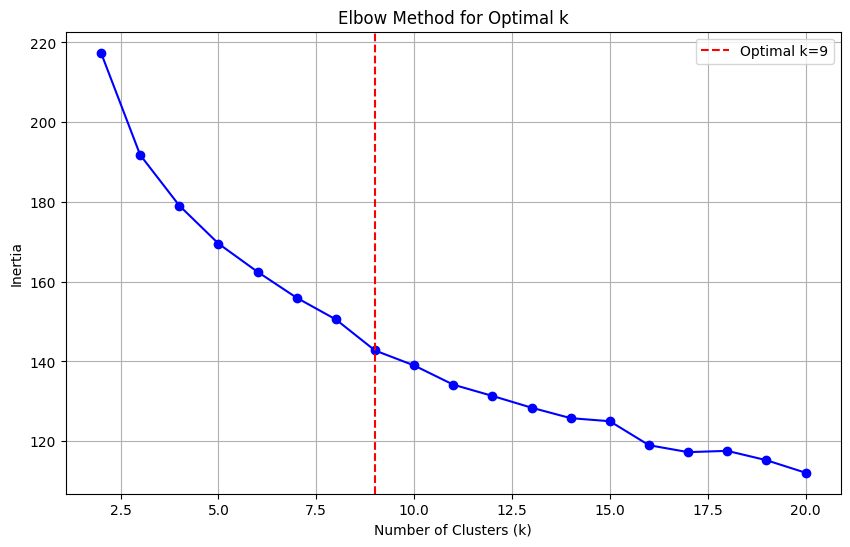

In [7]:
# Extract doc vectors from all_results
doc_vectors = []
doc_names = []

for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc_vectors.append(doc['doc_vector'])
        # Extract just the filename without path
        filename = os.path.basename(doc['file'])
        doc_names.append(filename)

# Convert to numpy array
doc_vectors_array = np.array(doc_vectors)

print(f"Total documents with vectors: {len(doc_vectors)}")
print(f"Vector dimensions: {doc_vectors_array.shape[1]}")

# Determine optimal number of clusters using elbow method
inertias = []
K_range = range(2, min(21, len(doc_vectors)))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(doc_vectors_array)
    inertias.append(kmeans.inertia_)

# Automatically detect the elbow point
kl = KneeLocator(
    list(K_range), 
    inertias, 
    curve='convex', 
    direction='decreasing'
)
optimal_k = kl.elbow if kl.elbow is not None else 8

print(f"Optimal number of clusters detected: {optimal_k}")

# Plot elbow curve with optimal point marked
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.grid(True)
plt.show()

# Perform clustering with the optimal number of clusters
n_clusters = optimal_k

<h5> By using the discovered number of clusters, we perform the K-Means algorithm to put each document in the closest cluster based on the weighted mean derived from page embeddings </h5>

In [8]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(doc_vectors_array)

# Add cluster labels to all_results
cluster_idx = 0
for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc['cluster'] = int(cluster_labels[cluster_idx])
        cluster_idx += 1

# Display clustering results
print(f"Clustering complete with {n_clusters} clusters")
print("Cluster distribution:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} documents")

# Show sample documents from each cluster
print("Sample documents per cluster:")
for i in range(n_clusters):
    cluster_docs = [doc_names[j] for j in range(len(doc_names)) if cluster_labels[j] == i]
    print(f"Cluster {i} ({len(cluster_docs)} docs):")
    # Show first 5 documents
    for doc in cluster_docs[:5]:
        print(f"  - {doc}")
    if len(cluster_docs) > 5:
        print(f"  ... and {len(cluster_docs) - 5} more")

Clustering complete with 9 clusters
Cluster distribution:
Cluster 0: 130 documents
Cluster 1: 59 documents
Cluster 2: 234 documents
Cluster 3: 164 documents
Cluster 4: 169 documents
Cluster 5: 160 documents
Cluster 6: 72 documents
Cluster 7: 28 documents
Cluster 8: 48 documents
Sample documents per cluster:
Cluster 0 (130 docs):
  - Fortimo_SLM_C_1201_L09_1313_G7N_HE_plus_.pdf
  - Fortimo_SLM_C_1211_L19_2828_G7_HE_plus_.pdf
  - Fortimo_SLM_PW_1206_L13_2024_G7.pdf
  - Fortimo_SLM_C_1203_L09_1313_G7N_HE_plus_.pdf
  - Fortimo_SLM_PW_1211_L19_2828_G7_.pdf
  ... and 125 more
Cluster 1 (59 docs):
  - InteGrade-S-commercial-leaflet.pdf
  - InteGrade_F_NB_Va_1460mm_Rose_G4.pdf
  - 143366_Commercial_Leaflet_RDL_PremiumWhite_fashion_LR.pdf
  - Datasheet_35_106_1002_85_Louvre_optics_Wide.pdf
  - 181716_Philips_PrimeSet_RDL500_510_leaflet_A04.pdf
  ... and 54 more
Cluster 2 (234 docs):
  - Xitanium_30W_a_0.6_0.75A_40V_3CW_230V_929002103606.pdf
  - Xitanium-50W_WH_0.7-1.5A_54V_SR_Is_230V_9290028613

<h5> Sorting documents to folders based on the cluster belogining. </h5>

In [9]:
# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters-06")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename for destination
            original_filename = os.path.basename(doc['file'])
            
            # Source file path (use the full path from doc['file'])
            source_file = doc['file']
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, original_filename)
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
            else:
                print(f"Warning: File not found: {source_file}")
    
    print(f"Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"All files organized into {clusters_main_dir}")

Cluster 0: 130 files copied to data_output/clusters-06/cluster0
Cluster 1: 59 files copied to data_output/clusters-06/cluster1
Cluster 2: 234 files copied to data_output/clusters-06/cluster2
Cluster 3: 164 files copied to data_output/clusters-06/cluster3
Cluster 4: 169 files copied to data_output/clusters-06/cluster4
Cluster 5: 160 files copied to data_output/clusters-06/cluster5
Cluster 6: 72 files copied to data_output/clusters-06/cluster6
Cluster 7: 28 files copied to data_output/clusters-06/cluster7
Cluster 8: 48 files copied to data_output/clusters-06/cluster8
All files organized into data_output/clusters-06
